# Euclidean vs. Cosine Metric — DBGSOM Comparison

This notebook compares `metric='euclidean'` and `metric='cosine'` on **scale-variant directional data**: clusters that share similar _directions_ but differ strongly in _magnitude_. Cosine distance ignores magnitude and focuses on direction; Euclidean distance treats magnitude differences as real separations.


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA

from dbgsom.SomVQ import SomVQ

## Dataset: Scale-Variant Directional Clusters

Three directional clusters (0°, 120°, 240°) with **random radii** — some samples are close to the origin, others far away. Each cluster is split into a _near_ and _far_ sub-group to create scale variation.

- **Euclidean SOM** sees the near and far sub-groups as separate and may split them across neurons.
- **Cosine SOM** treats them identically since they point in the same direction.


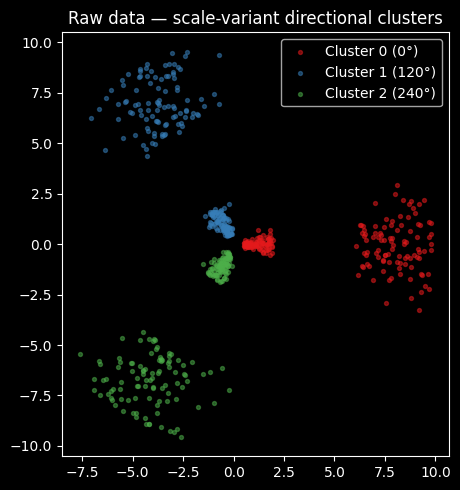

In [2]:
rng = np.random.default_rng(42)
n_per_cluster = 200
angles_deg = [0, 120, 240]
colors = ["#e41a1c", "#377eb8", "#4daf4a"]

X_parts, true_labels = [], []
for label, angle in enumerate(angles_deg):
    theta = np.radians(angle + rng.normal(0, 10, n_per_cluster))
    # mix of near (r~1) and far (r~8) samples
    r = np.concatenate(
        [
            rng.uniform(0.5, 2.0, n_per_cluster // 2),
            rng.uniform(6.0, 10.0, n_per_cluster // 2),
        ]
    )
    rng.shuffle(r)
    X_parts.append(np.column_stack([r * np.cos(theta), r * np.sin(theta)]))
    true_labels.extend([label] * n_per_cluster)

X = np.vstack(X_parts)
true_labels = np.array(true_labels)

fig, ax = plt.subplots(figsize=(5, 5))
for label, color in enumerate(colors):
    mask = true_labels == label
    ax.scatter(
        X[mask, 0],
        X[mask, 1],
        c=color,
        s=8,
        alpha=0.5,
        label=f"Cluster {label} ({angles_deg[label]}°)",
    )
ax.set_title("Raw data — scale-variant directional clusters")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

## Train Both SOMs


In [3]:
params = dict(
    random_state=42, n_iter=1000, max_neurons=30, verbose=False, convergence_iter=50
)

t0 = time.perf_counter()
som_euc = SomVQ(**params, metric="euclidean").fit(X)
t_euc = time.perf_counter() - t0

t0 = time.perf_counter()
som_cos = SomVQ(**params, metric="cosine").fit(X)
t_cos = time.perf_counter() - t0

print(f"{'':25s} {'Euclidean':>12s} {'Cosine':>12s}")
print("-" * 51)
print(
    f"{'Neurons':25s} {som_euc.som_.number_of_nodes():>12d} {som_cos.som_.number_of_nodes():>12d}"
)
print(
    f"{'Quantization error':25s} {som_euc.quantization_error_:>12.4f} {som_cos.quantization_error_:>12.4f}"
)
print(
    f"{'Topographic error':25s} {som_euc.topographic_error_:>12.4f} {som_cos.topographic_error_:>12.4f}"
)
print(f"{'Training time (s)':25s} {t_euc:>12.3f} {t_cos:>12.3f}")

                             Euclidean       Cosine
---------------------------------------------------
Neurons                              6            4
Quantization error              2.0750       0.0557
Topographic error               0.1417       0.0000
Training time (s)                3.126        1.460


## Cluster Assignments

Each sample is colored by the neuron it was assigned to. Neuron positions are shown as black dots connected by graph edges.


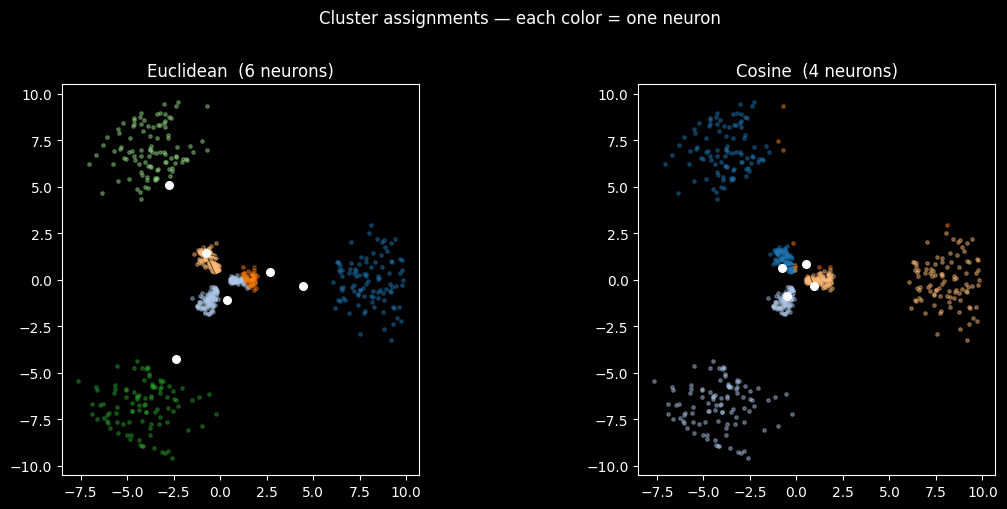

In [4]:
def plot_som_assignments(ax, som, X, title):
    labels = som.predict(X)
    palette = sns.color_palette("tab20", n_colors=som.som_.number_of_nodes())
    for neuron_idx in range(som.som_.number_of_nodes()):
        mask = labels == neuron_idx
        if mask.any():
            ax.scatter(
                X[mask, 0], X[mask, 1], color=palette[neuron_idx], s=6, alpha=0.4
            )
    for u, v in som.som_.edges():
        wu = som.som_.nodes[u]["weight"]
        wv = som.som_.nodes[v]["weight"]
        ax.plot([wu[0], wv[0]], [wu[1], wv[1]], "k-", linewidth=0.8, alpha=0.6)
    ax.scatter(som.weights_[:, 0], som.weights_[:, 1], c="white", s=30, zorder=5)
    ax.set_title(title)
    ax.set_aspect("equal")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_som_assignments(
    axes[0], som_euc, X, f"Euclidean  ({som_euc.som_.number_of_nodes()} neurons)"
)
plot_som_assignments(
    axes[1], som_cos, X, f"Cosine  ({som_cos.som_.number_of_nodes()} neurons)"
)
plt.suptitle("Cluster assignments — each color = one neuron", y=1.01)
plt.tight_layout()
plt.show()

## Neuron Positions in Weight Space

For 2D data the neurons can be plotted directly. The cosine neurons lie on the **unit circle** (each weight vector has norm 1); the Euclidean neurons adapt their magnitude to the data.


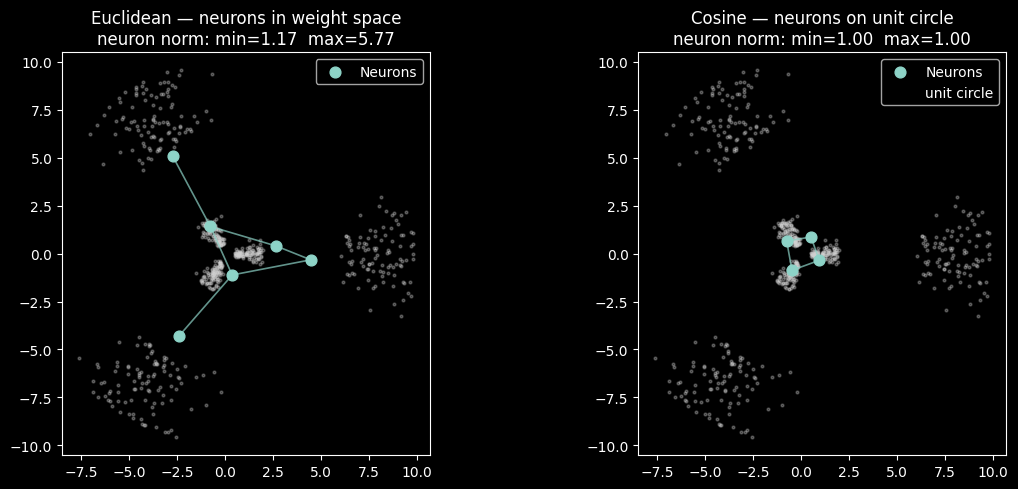

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, som, title in [
    (axes[0], som_euc, "Euclidean — neurons in weight space"),
    (axes[1], som_cos, "Cosine — neurons on unit circle"),
]:
    ax.scatter(X[:, 0], X[:, 1], c="lightgray", s=4, alpha=0.3, zorder=1)
    for u, v in som.som_.edges():
        wu = som.som_.nodes[u]["weight"]
        wv = som.som_.nodes[v]["weight"]
        ax.plot(
            [wu[0], wv[0]], [wu[1], wv[1]], "C0-", linewidth=1.2, alpha=0.7, zorder=2
        )
    ax.scatter(
        som.weights_[:, 0], som.weights_[:, 1], c="C0", s=60, zorder=3, label="Neurons"
    )
    norms = np.linalg.norm(som.weights_, axis=1)
    ax.set_title(f"{title}\nneuron norm: min={norms.min():.2f}  max={norms.max():.2f}")
    ax.set_aspect("equal")
    ax.legend()

# draw unit circle on cosine plot
theta = np.linspace(0, 2 * np.pi, 200)
axes[1].plot(
    np.cos(theta), np.sin(theta), "k--", linewidth=0.8, alpha=0.4, label="unit circle"
)
axes[1].legend()

plt.tight_layout()
plt.show()

## Topographic Function

The topographic function shows how many data points are _misplaced_ as the allowed distance threshold increases. A steeper initial drop indicates better topographic preservation.


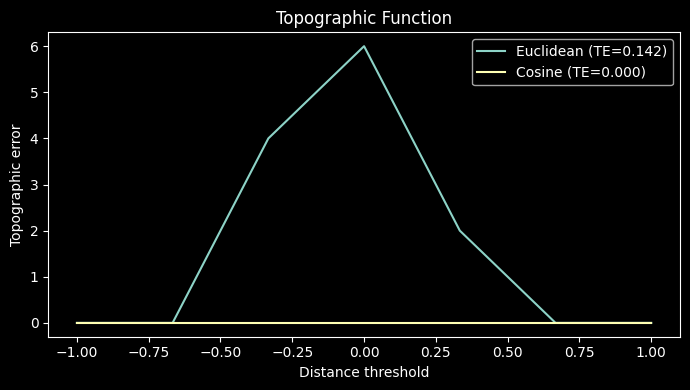

In [6]:
te_euc = som_euc.topographic_function(X)
te_cos = som_cos.topographic_function(X)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(te_euc[1], te_euc[0], label=f"Euclidean (TE={som_euc.topographic_error_:.3f})")
ax.plot(te_cos[1], te_cos[0], label=f"Cosine (TE={som_cos.topographic_error_:.3f})")
ax.set_xlabel("Distance threshold")
ax.set_ylabel("Topographic error")
ax.set_title("Topographic Function")
ax.legend()
plt.tight_layout()
plt.show()

---
## High-Dimensional Example (50 Dimensions)

In 2D, normalising collapses all data onto the unit circle — too simple for a growing SOM.
Here we use **50-dimensional** directional clusters with a 100× scale range.
Each cluster is defined by a random direction vector; samples are random multiples of
that direction plus noise.

**Adjusted Rand Index (ARI)** measures how well the SOM cluster assignments recover the
true labels (1 = perfect, 0 = random). This is the key comparison metric here.

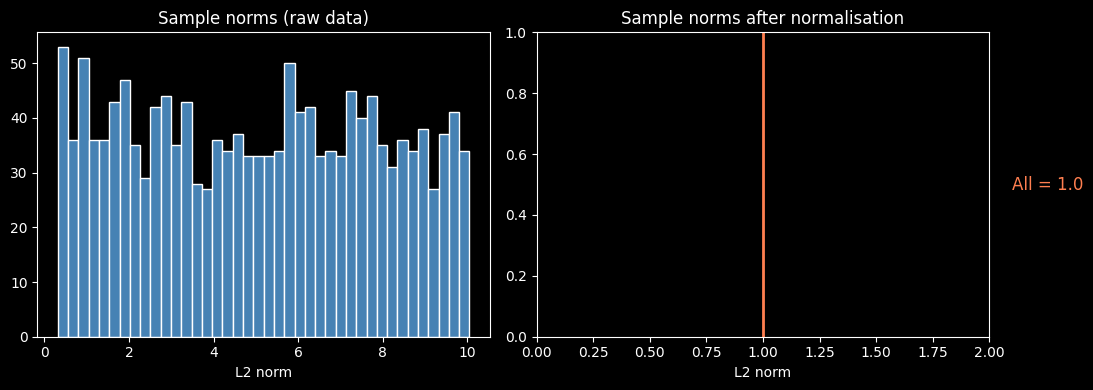

Shape: (1500, 50)  |  norm range: [0.32, 10.05]


In [7]:
from sklearn.metrics import adjusted_rand_score

rng_hd = np.random.default_rng(0)
n_clusters, n_dims, n_per_cluster = 5, 50, 300

directions = rng_hd.standard_normal((n_clusters, n_dims))
directions /= np.linalg.norm(directions, axis=1, keepdims=True)

X_hd_parts, y_hd = [], []
for k, d in enumerate(directions):
    scale = rng_hd.uniform(0.1, 10.0, n_per_cluster)
    noise = rng_hd.standard_normal((n_per_cluster, n_dims)) * 0.05
    X_hd_parts.append(scale[:, None] * d + noise)
    y_hd.extend([k] * n_per_cluster)

X_hd = np.vstack(X_hd_parts)
y_hd = np.array(y_hd)

raw_norms = np.linalg.norm(X_hd, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(raw_norms, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Sample norms (raw data)")
axes[0].set_xlabel("L2 norm")
axes[1].axvline(1.0, color="coral", linewidth=2)
axes[1].set_xlim(0, 2)
axes[1].set_title("Sample norms after normalisation")
axes[1].set_xlabel("L2 norm")
axes[1].text(
    1.05,
    0.5,
    "All = 1.0",
    transform=axes[1].get_yaxis_transform(),
    va="center",
    color="coral",
    fontsize=12,
)
plt.tight_layout()
plt.show()
print(
    f"Shape: {X_hd.shape}  |  norm range: [{raw_norms.min():.2f}, {raw_norms.max():.2f}]"
)

In [8]:
params_hd = dict(
    random_state=42,
    n_iter=200,
    max_neurons=25,
    spreading_factor=0.7,
    verbose=False,
    convergence_iter=10,
)

t0 = time.perf_counter()
som_euc_hd = SomVQ(**params_hd, metric="euclidean").fit(X_hd)
t_euc_hd = time.perf_counter() - t0

t0 = time.perf_counter()
som_cos_hd = SomVQ(**params_hd, metric="cosine").fit(X_hd)
t_cos_hd = time.perf_counter() - t0

ari_euc = adjusted_rand_score(y_hd, som_euc_hd.predict(X_hd))
ari_cos = adjusted_rand_score(y_hd, som_cos_hd.predict(X_hd))

rows = [
    ("Neurons", som_euc_hd.som_.number_of_nodes(), som_cos_hd.som_.number_of_nodes()),
    (
        "Quantization error",
        round(som_euc_hd.quantization_error_, 4),
        round(som_cos_hd.quantization_error_, 4),
    ),
    (
        "Topographic error",
        round(som_euc_hd.topographic_error_, 4),
        round(som_cos_hd.topographic_error_, 4),
    ),
    ("ARI (cluster purity)", round(ari_euc, 4), round(ari_cos, 4)),
    ("Training time (s)", round(t_euc_hd, 3), round(t_cos_hd, 3)),
]
col1, col2 = "Euclidean", "Cosine"
print("{:25s} {:>12s} {:>12s}".format("", col1, col2))
print("-" * 51)
for label, v_euc, v_cos in rows:
    print("{:25s} {:>12} {:>12}".format(label, v_euc, v_cos))

                             Euclidean       Cosine
---------------------------------------------------
Neurons                             25            8
Quantization error              3.1207       0.0514
Topographic error               0.6093        0.006
ARI (cluster purity)            0.3884       0.9975
Training time (s)                0.123         0.21


## PCA Projection of Cluster Assignments

PCA projects the 50D data to 2D for visualisation. Each colour represents one neuron.
The cosine SOM should separate the 5 direction clusters cleanly despite their scale
variation; the Euclidean SOM may mix near and far samples from the same cluster.

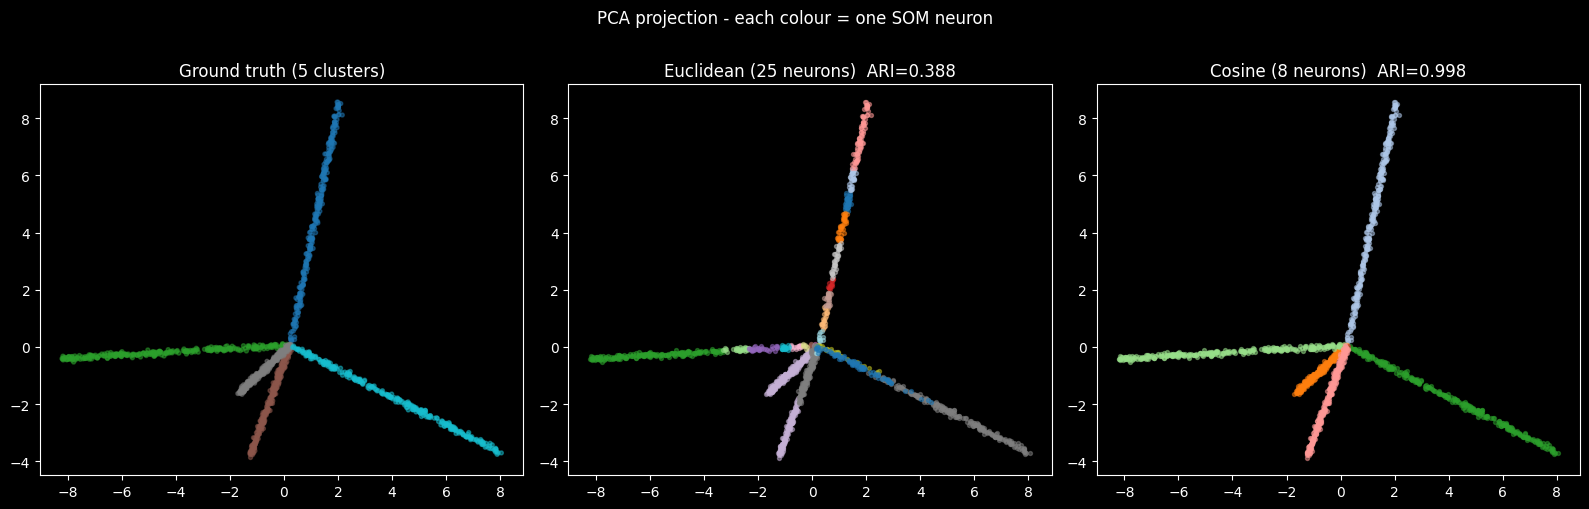

In [9]:
pca = PCA(n_components=2, random_state=42).fit(X_hd)
X_2d = pca.transform(X_hd)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_hd, cmap="tab10", s=8, alpha=0.5)
axes[0].set_title("Ground truth (5 clusters)")

for ax, som, title, ari in [
    (axes[1], som_euc_hd, "Euclidean", ari_euc),
    (axes[2], som_cos_hd, "Cosine", ari_cos),
]:
    labels = som.predict(X_hd)
    palette = sns.color_palette("tab20", n_colors=som.som_.number_of_nodes())
    for nidx in range(som.som_.number_of_nodes()):
        mask = labels == nidx
        if mask.any():
            ax.scatter(
                X_2d[mask, 0], X_2d[mask, 1], color=palette[nidx], s=8, alpha=0.5
            )
    n = som.som_.number_of_nodes()
    t = title + " (" + str(n) + " neurons)  ARI=" + str(round(ari, 3))
    ax.set_title(t)

plt.suptitle("PCA projection - each colour = one SOM neuron", y=1.01)
plt.tight_layout()
plt.show()